# Lecture 4: Risk in the Short Run and the Long Run

## Investment Analysis

This lecture studies a subtle but important problem in investment analysis:

> Does risk disappear when we hold assets for a long time?

The answer is no. Some risk measures become smaller when averaged over time, but cumulative wealth becomes more dispersed over longer horizons.

This lecture also distinguishes **risk pooling** from **risk sharing**, using insurance as the key example. Pooling many independent risks can make average losses more predictable, but the institution that pools risks must not accidentally scale up its aggregate exposure without also scaling up capital and investors.

The central lessons are:

1. The law of large numbers applies to averages, not to unlimited balance-sheet expansion.
2. Risk pooling reduces average uncertainty only when exposures are properly scaled.
3. Risk sharing spreads exposures across investors.
4. Time diversification can be misleading.
5. Average annual returns become more predictable over long horizons, but cumulative returns become more uncertain.

# 1. Learning Objectives

By the end of this lecture, students should be able to:

1. Explain the difference between short-run and long-run risk.
2. Distinguish average annual returns from cumulative returns.
3. Explain why the annualized average return becomes less volatile as the horizon increases.
4. Explain why cumulative wealth becomes more volatile as the horizon increases.
5. Define risk pooling and risk sharing.
6. Explain why an insurer must scale capital and investor participation as it adds policies.
7. Describe the error involved in the fallacy of time diversification.
8. Calculate means, standard deviations, and Value at Risk for average and cumulative returns.
9. Simulate long-horizon return distributions.
10. Interpret the difference between arithmetic and geometric compounding in long-run risk.

# 2. Setup: Python Libraries

The notebook uses simple simulations. The goal is to make the logic visible.

We will simulate both:

1. independent insurance losses, and
2. investment returns over different horizons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(123)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 3. Short-Run Risk Versus Long-Run Risk

Investment risk changes with the horizon, but not always in the way students first expect.

Suppose a risky asset has independent annual returns:

$$
R_1, R_2, \ldots, R_T
$$

with:

$$
\mathbb{E}[R_t] = \mu
$$

and:

$$
\operatorname{Var}(R_t) = \sigma^2
$$

The arithmetic average annual return over \(T\) years is:

$$
\bar{R}_T = \frac{1}{T}\sum_{t=1}^T R_t
$$

If returns are independent, then:

$$
\operatorname{Var}(\bar{R}_T)
=
\frac{\sigma^2}{T}
$$

and:

$$
\operatorname{Std}(\bar{R}_T)
=
\frac{\sigma}{\sqrt{T}}
$$

So the average annual return becomes more predictable as the horizon grows.

But cumulative returns behave differently.

# 4. Cumulative Returns Become Riskier with Time

The cumulative simple gross return over \(T\) years is:

$$
1+R_{0,T}
=
\prod_{t=1}^T (1+R_t)
$$

The cumulative simple return is:

$$
R_{0,T}
=
\prod_{t=1}^T (1+R_t)-1
$$

If we use continuously compounded returns \(r_t\), then cumulative log return is:

$$
r_{0,T}
=
\sum_{t=1}^T r_t
$$

If log returns are independent with variance \(\sigma_r^2\), then:

$$
\operatorname{Var}(r_{0,T}) = T\sigma_r^2
$$

and:

$$
\operatorname{Std}(r_{0,T}) = \sqrt{T}\sigma_r
$$

So the average return per year becomes less volatile, but the cumulative return becomes more volatile.

That is the key distinction.

# 5. The Fallacy of Time Diversification

The **fallacy of time diversification** is the claim that stocks or other risky assets become safe merely because the investor holds them for a long time.

The claim often confuses two different objects:

1. average annual return,
2. cumulative terminal wealth.

It is true that the average annual return becomes more statistically precise as the sample horizon grows.

But it is false that terminal wealth becomes safe.

The distribution of cumulative wealth spreads out as the horizon grows.

A long horizon gives the risk premium more time to compound, but it also gives shocks more time to accumulate.

A compact way to see the point is with log returns.

Let annual log return be:

$$
r_t \sim N(\mu, \sigma^2)
$$

Then the \(T\)-year cumulative log return is:

$$
r_{0,T} = \sum_{t=1}^T r_t
$$

Its mean is:

$$
\mathbb{E}[r_{0,T}] = T\mu
$$

Its standard deviation is:

$$
\operatorname{Std}(r_{0,T}) = \sqrt{T}\sigma
$$

The average annual log return is:

$$
\bar{r}_T = \frac{1}{T}r_{0,T}
$$

Its mean is:

$$
\mathbb{E}[\bar{r}_T] = \mu
$$

Its standard deviation is:

$$
\operatorname{Std}(\bar{r}_T) = \frac{\sigma}{\sqrt{T}}
$$

Thus:

- average return risk falls with horizon,
- cumulative return risk rises with horizon.

In [2]:
# Demonstration: average annual log return risk falls, cumulative log return risk rises

mu_log = 0.06
sigma_log = 0.18

horizons = np.array([1, 2, 5, 10, 20, 30, 40])

summary = pd.DataFrame({
    "Horizon T": horizons,
    "Mean Cumulative Log Return": horizons * mu_log,
    "Std Dev Cumulative Log Return": np.sqrt(horizons) * sigma_log,
    "Mean Average Annual Log Return": mu_log,
    "Std Dev Average Annual Log Return": sigma_log / np.sqrt(horizons)
})

summary

,Horizon T,Mean Cumulative Log Return,Std Dev Cumulative Log Return,Mean Average Annual Log Return,Std Dev Average Annual Log Return
0,1,0.0600,0.1800,0.0600,0.1800
1,2,0.1200,0.2546,0.0600,0.1273
2,5,0.3000,0.4025,0.0600,0.0805
3,10,0.6000,0.5692,0.0600,0.0569
4,20,1.2000,0.8050,0.0600,0.0402
5,30,1.8000,0.9859,0.0600,0.0329
6,40,2.4000,1.1384,0.0600,0.0285


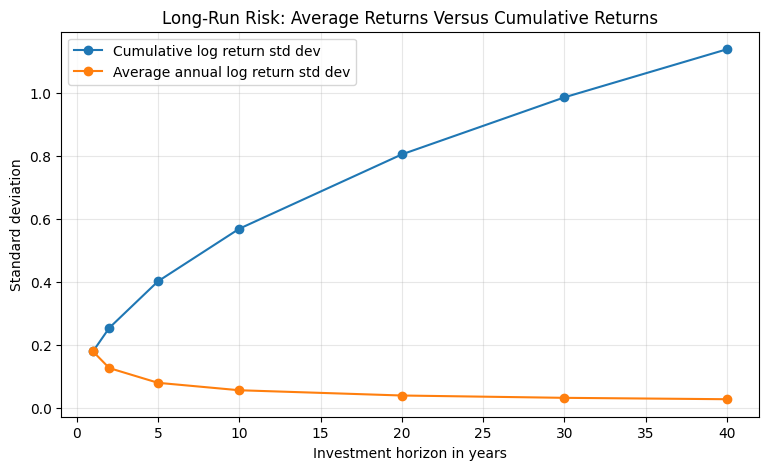

In [3]:
plt.figure(figsize=(9, 5))
plt.plot(horizons, np.sqrt(horizons) * sigma_log, marker="o", label="Cumulative log return std dev")
plt.plot(horizons, sigma_log / np.sqrt(horizons), marker="o", label="Average annual log return std dev")
plt.xlabel("Investment horizon in years")
plt.ylabel("Standard deviation")
plt.title("Long-Run Risk: Average Returns Versus Cumulative Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The graph contains the core lesson.

Averages become more stable over longer horizons.

Cumulative outcomes become more dispersed over longer horizons.

# 6. Worked Example: One-Year, Ten-Year, and Thirty-Year Risk

Suppose annual log returns are normally distributed with:

$$
\mu = 6\%
$$

and:

$$
\sigma = 18\%
$$

We compare horizons of 1, 10, and 30 years.

For cumulative log returns:

$$
r_{0,T} \sim N(T\mu, T\sigma^2)
$$

For average annual log returns:

$$
\bar{r}_T \sim N\left(\mu, \frac{\sigma^2}{T}\right)
$$

For a 5% Value at Risk statistic, using the left-tail normal critical value:

$$
z_{0.05} \approx -1.645
$$

The 5th percentile of average annual log return is:

$$
\mu + z_{0.05}\frac{\sigma}{\sqrt{T}}
$$

The 5th percentile of cumulative log return is:

$$
T\mu + z_{0.05}\sqrt{T}\sigma
$$

In [4]:
# Worked example: VaR statistics for average and cumulative log returns

z_05 = -1.6448536269514729

horizons_worked = np.array([1, 10, 30])

worked = pd.DataFrame({
    "Horizon T": horizons_worked,
    "Mean Average Annual Log Return": mu_log,
    "Std Dev Average Annual Log Return": sigma_log / np.sqrt(horizons_worked),
    "5th Percentile Average Annual Log Return": mu_log + z_05 * sigma_log / np.sqrt(horizons_worked),
    "Mean Cumulative Log Return": horizons_worked * mu_log,
    "Std Dev Cumulative Log Return": np.sqrt(horizons_worked) * sigma_log,
    "5th Percentile Cumulative Log Return": horizons_worked * mu_log + z_05 * np.sqrt(horizons_worked) * sigma_log,
})

worked["5th Percentile Cumulative Gross Return"] = np.exp(worked["5th Percentile Cumulative Log Return"]) - 1
worked["Median Cumulative Gross Return"] = np.exp(worked["Mean Cumulative Log Return"]) - 1

worked

,Horizon T,Mean Average Annual Log Return,Std Dev Average Annual Log Return,5th Percentile Average Annual Log Return,Mean Cumulative Log Return,Std Dev Cumulative Log Return,5th Percentile Cumulative Log Return,5th Percentile Cumulative Gross Return,Median Cumulative Gross Return
0,1,0.0600,0.1800,-0.2361,0.0600,0.1800,-0.2361,-0.2103,0.0618
1,10,0.0600,0.0569,-0.0336,0.6000,0.5692,-0.3363,-0.2856,0.8221
2,30,0.0600,0.0329,0.0059,1.8000,0.9859,0.1783,0.1952,5.0496


The table shows two different types of long-horizon statements.

For the average annual return, the left-tail outcome becomes less severe as \(T\) rises.

For cumulative returns, the left-tail dollar outcome can still be severe because the cumulative return distribution becomes more spread out.

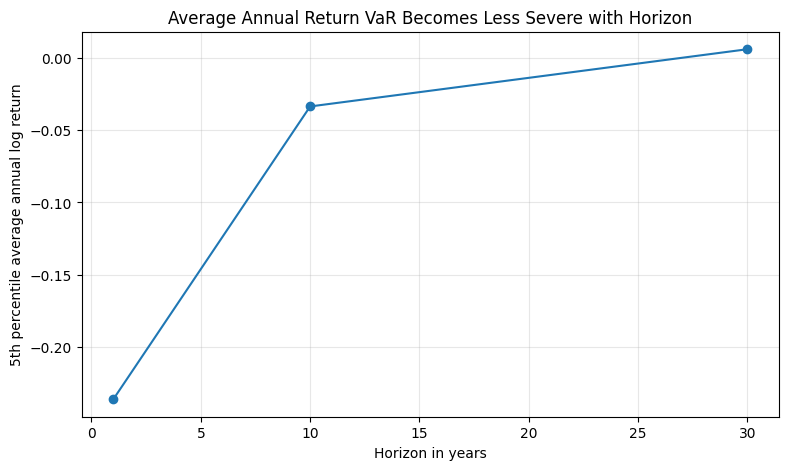

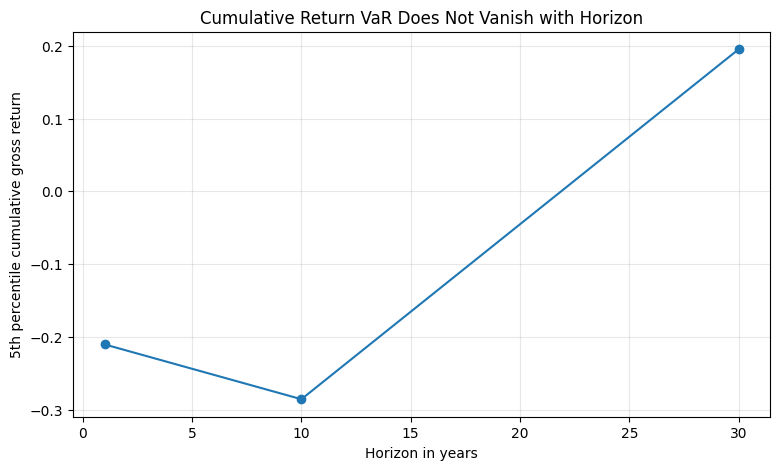

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(horizons_worked, worked["5th Percentile Average Annual Log Return"], marker="o")
plt.xlabel("Horizon in years")
plt.ylabel("5th percentile average annual log return")
plt.title("Average Annual Return VaR Becomes Less Severe with Horizon")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(horizons_worked, worked["5th Percentile Cumulative Gross Return"], marker="o")
plt.xlabel("Horizon in years")
plt.ylabel("5th percentile cumulative gross return")
plt.title("Cumulative Return VaR Does Not Vanish with Horizon")
plt.grid(True, alpha=0.3)
plt.show()

# 7. Simulated Long-Horizon Return Distributions

The formulas are useful, but simulation helps students see the distribution.

We simulate many paths of annual log returns and compare:

1. average annual log return,
2. cumulative log return,
3. terminal wealth from a $1 initial investment.

In [6]:
# Simulation of long-horizon log returns

num_paths = 100_000
horizons_sim = [1, 10, 30]

sim_rows = []

terminal_wealth_by_horizon = {}
average_log_by_horizon = {}
cumulative_log_by_horizon = {}

for T in horizons_sim:
    annual_log_returns = np.random.normal(mu_log, sigma_log, size=(num_paths, T))
    cumulative_log = annual_log_returns.sum(axis=1)
    average_log = cumulative_log / T
    terminal_wealth = np.exp(cumulative_log)

    terminal_wealth_by_horizon[T] = terminal_wealth
    average_log_by_horizon[T] = average_log
    cumulative_log_by_horizon[T] = cumulative_log

    sim_rows.append({
        "Horizon T": T,
        "Mean Average Annual Log Return": average_log.mean(),
        "Std Dev Average Annual Log Return": average_log.std(ddof=1),
        "5% VaR Average Annual Log Return": np.quantile(average_log, 0.05),
        "Mean Cumulative Log Return": cumulative_log.mean(),
        "Std Dev Cumulative Log Return": cumulative_log.std(ddof=1),
        "5% VaR Cumulative Log Return": np.quantile(cumulative_log, 0.05),
        "Median Terminal Wealth": np.median(terminal_wealth),
        "5% Terminal Wealth": np.quantile(terminal_wealth, 0.05),
        "1% Terminal Wealth": np.quantile(terminal_wealth, 0.01),
        "Mean Terminal Wealth": terminal_wealth.mean()
    })

sim_summary = pd.DataFrame(sim_rows)
sim_summary

,Horizon T,Mean Average Annual Log Return,Std Dev Average Annual Log Return,5% VaR Average Annual Log Return,Mean Cumulative Log Return,Std Dev Cumulative Log Return,5% VaR Cumulative Log Return,Median Terminal Wealth,5% Terminal Wealth,1% Terminal Wealth,Mean Terminal Wealth
0,1,0.0602,0.1799,-0.2347,0.0602,0.1799,-0.2347,1.0622,0.7908,0.6994,1.0794
1,10,0.0600,0.0569,-0.0334,0.6000,0.5692,-0.3344,1.8247,0.7158,0.4835,2.1423
2,30,0.0601,0.0330,0.0060,1.8031,0.9893,0.1786,6.0725,1.1955,0.6031,9.8911


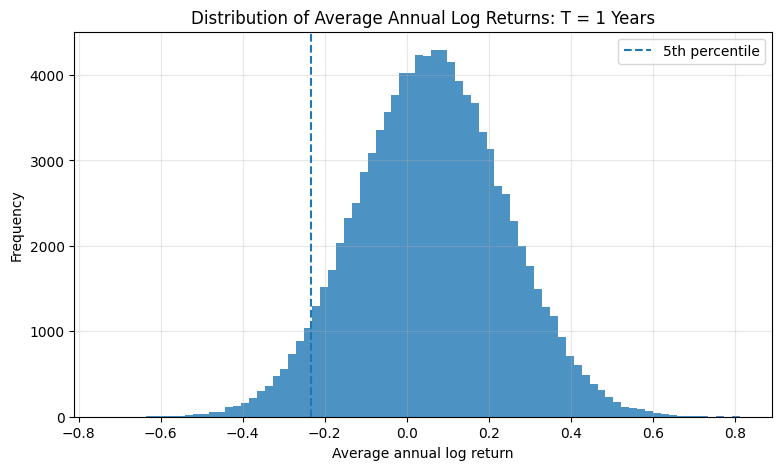

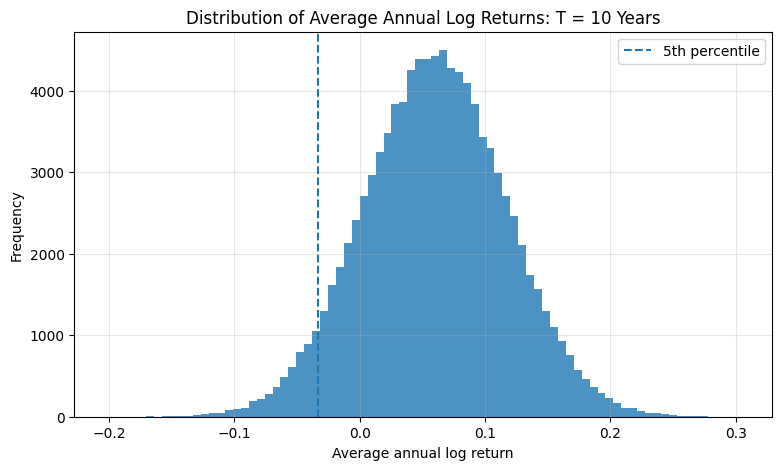

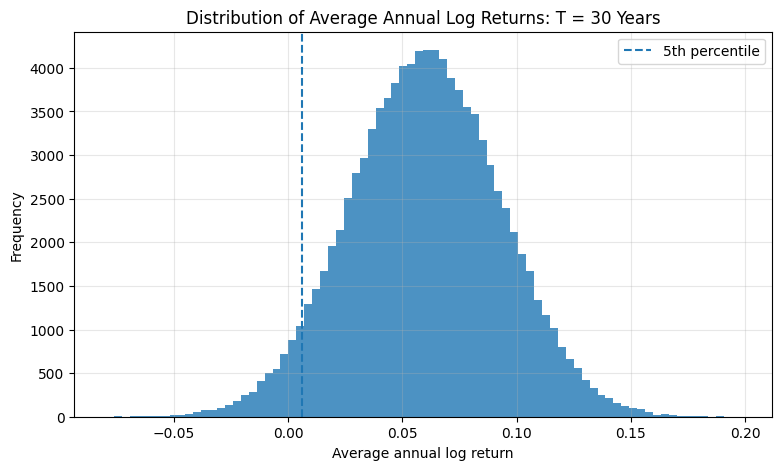

In [7]:
# Histograms of average annual log returns

for T in horizons_sim:
    plt.figure(figsize=(9, 5))
    plt.hist(average_log_by_horizon[T], bins=80, alpha=0.8)
    plt.axvline(np.quantile(average_log_by_horizon[T], 0.05), linestyle="--", label="5th percentile")
    plt.xlabel("Average annual log return")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Average Annual Log Returns: T = {T} Years")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

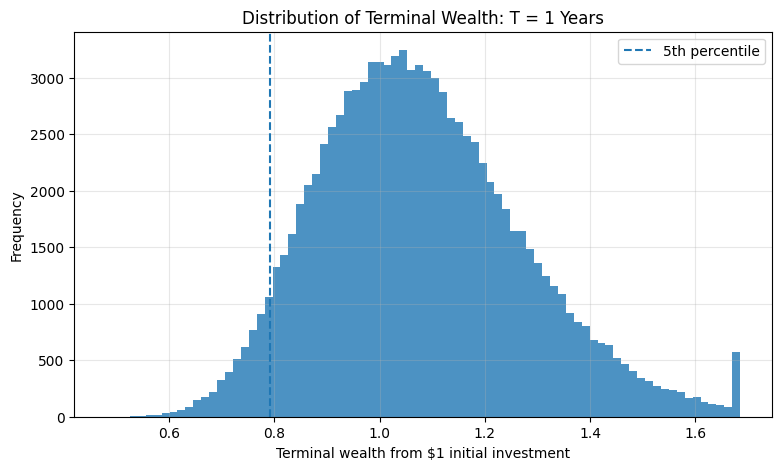

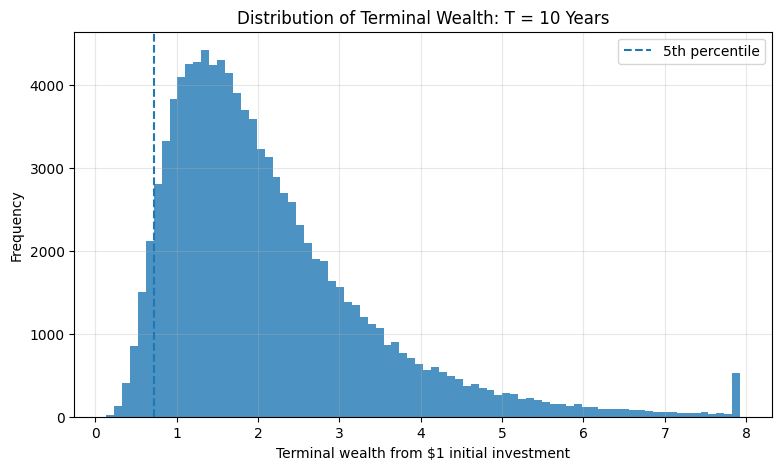

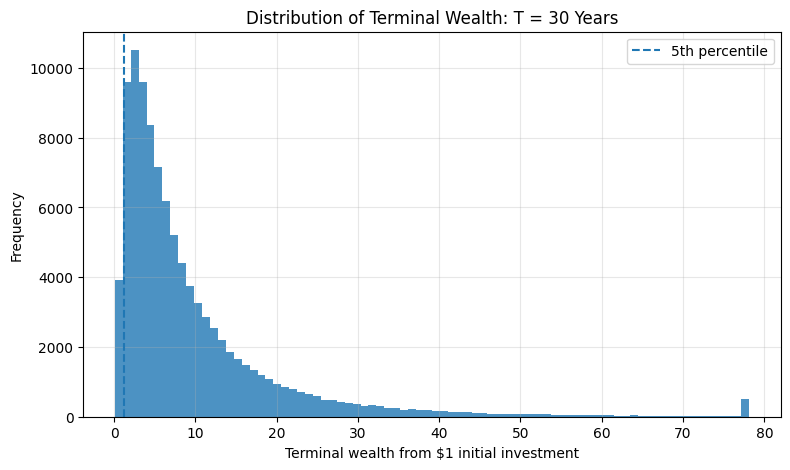

In [8]:
# Histograms of terminal wealth

for T in horizons_sim:
    plt.figure(figsize=(9, 5))
    capped = np.minimum(terminal_wealth_by_horizon[T], np.quantile(terminal_wealth_by_horizon[T], 0.995))
    plt.hist(capped, bins=80, alpha=0.8)
    plt.axvline(np.quantile(terminal_wealth_by_horizon[T], 0.05), linestyle="--", label="5th percentile")
    plt.xlabel("Terminal wealth from $1 initial investment")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Terminal Wealth: T = {T} Years")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

The average annual return distributions tighten as the horizon increases.

The terminal wealth distributions do not tighten. They become more skewed and more dispersed.

That is why it is misleading to say that a long horizon makes a risky asset safe.

# 8. Value at Risk for Average Returns and Cumulative Returns

**Value at Risk**, or VaR, is a loss quantile.

There are two common but different objects we might compute:

1. VaR for the average annual return.
2. VaR for cumulative terminal wealth.

For average annual log returns:

$$
\operatorname{VaR}_{5\%}^{avg}
=
-\left(\mu + z_{0.05}\frac{\sigma}{\sqrt{T}}\right)
$$

if we report the negative of the 5th-percentile return as a positive loss number.

For cumulative log returns:

$$
\operatorname{VaR}_{5\%}^{cum}
=
-\left(T\mu + z_{0.05}\sqrt{T}\sigma\right)
$$

But for terminal wealth, the loss relative to initial wealth is:

$$
\operatorname{Loss}_{T}
=
1-\exp(r_{0,T})
$$

at the relevant quantile.

The choice of VaR object matters.

In [9]:
# VaR for average and cumulative returns across horizons

horizons_var = np.arange(1, 41)

avg_5pct = mu_log + z_05 * sigma_log / np.sqrt(horizons_var)
cum_5pct_log = horizons_var * mu_log + z_05 * np.sqrt(horizons_var) * sigma_log
terminal_wealth_5pct = np.exp(cum_5pct_log)
loss_vs_initial_5pct = 1 - terminal_wealth_5pct

var_table = pd.DataFrame({
    "Horizon": horizons_var,
    "5th Pct Average Annual Log Return": avg_5pct,
    "5th Pct Cumulative Log Return": cum_5pct_log,
    "5th Pct Terminal Wealth from $1": terminal_wealth_5pct,
    "Loss from $1 at 5th Pct": loss_vs_initial_5pct
})

var_table.iloc[[0, 4, 9, 19, 29, 39]]

,Horizon,5th Pct Average Annual Log Return,5th Pct Cumulative Log Return,5th Pct Terminal Wealth from $1,Loss from $1 at 5th Pct
0,1,-0.2361,-0.2361,0.7897,0.2103
4,5,-0.0724,-0.3620,0.6963,0.3037
9,10,-0.0336,-0.3363,0.7144,0.2856
19,20,-0.0062,-0.1241,0.8833,0.1167
29,30,0.0059,0.1783,1.1952,-0.1952
39,40,0.0132,0.5275,1.6946,-0.6946


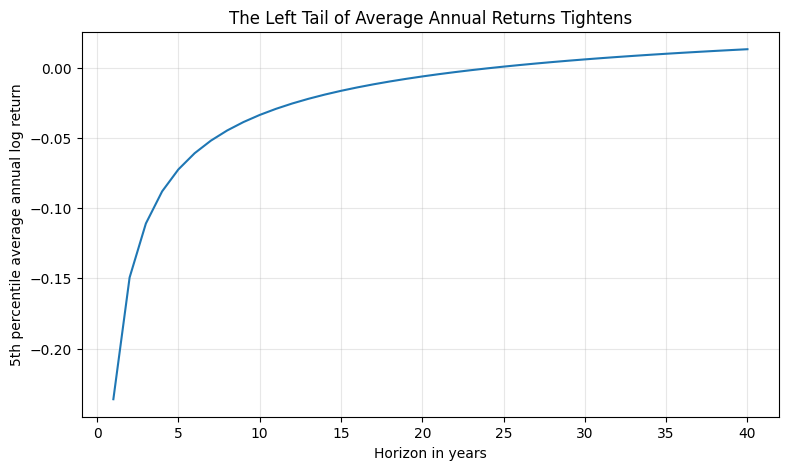

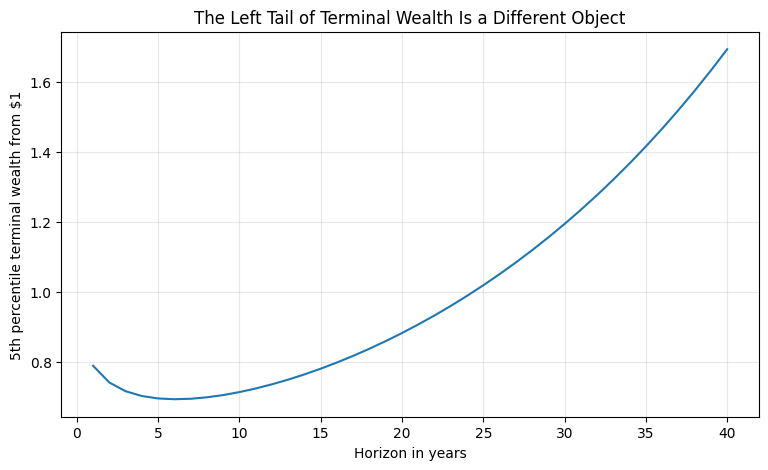

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(horizons_var, avg_5pct)
plt.xlabel("Horizon in years")
plt.ylabel("5th percentile average annual log return")
plt.title("The Left Tail of Average Annual Returns Tightens")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(horizons_var, terminal_wealth_5pct)
plt.xlabel("Horizon in years")
plt.ylabel("5th percentile terminal wealth from $1")
plt.title("The Left Tail of Terminal Wealth Is a Different Object")
plt.grid(True, alpha=0.3)
plt.show()

The 5th percentile average annual return improves with horizon because annual averages become more stable.

But terminal wealth can still have a wide range of possible outcomes.

The mean may rise, the median may rise, and yet economically meaningful downside risk remains.

# 9. Risk Pooling Versus Risk Sharing

The insurance example clarifies the difference between two ideas that are often blended together.

## Risk pooling

Risk pooling combines many imperfectly correlated or independent risks into one pool.

Example:

An insurance company writes many policies. Each policy has a small probability of a claim.

If claims are independent, the average claim per policy becomes more predictable as the number of policies grows.

This is the law of large numbers.

## Risk sharing

Risk sharing spreads the pooled risk across many investors, policyholders, reinsurers, or capital providers.

Risk pooling reduces the uncertainty of average loss per policy.

Risk sharing determines who bears the aggregate loss.

Both are necessary.

# 10. Insurance Policy Example

Suppose each insurance policy has:

- probability of claim \(p = 2\%\),
- claim size \(L = \$100{,}000\),
- expected loss per policy:

$$
\mathbb{E}[\ell] = pL
$$

The variance of the loss on one policy is:

$$
\operatorname{Var}(\ell)
=
p(1-p)L^2
$$

If the insurer writes \(N\) independent policies, total claims are:

$$
X_N = \sum_{i=1}^N \ell_i
$$

Expected total claims are:

$$
\mathbb{E}[X_N] = NpL
$$

Variance of total claims is:

$$
\operatorname{Var}(X_N) = Np(1-p)L^2
$$

Standard deviation of total claims is:

$$
\operatorname{Std}(X_N) = \sqrt{Np(1-p)}L
$$

Average claim per policy is:

$$
\bar{X}_N = \frac{X_N}{N}
$$

The standard deviation of average claim per policy is:

$$
\operatorname{Std}(\bar{X}_N)
=
\frac{\sqrt{Np(1-p)}L}{N}
=
\frac{\sqrt{p(1-p)}L}{\sqrt{N}}
$$

Average loss becomes more predictable.

But total loss becomes larger and more volatile in dollars.

In [11]:
# Insurance example: average losses become predictable, total losses grow

p = 0.02
L = 100_000

N_policies = np.array([10, 100, 1_000, 10_000, 100_000])

insurance_table = pd.DataFrame({
    "Number of Policies": N_policies,
    "Expected Total Claims": N_policies * p * L,
    "Std Dev Total Claims": np.sqrt(N_policies * p * (1-p)) * L,
    "Expected Average Claim per Policy": p * L,
    "Std Dev Average Claim per Policy": np.sqrt(p*(1-p)) * L / np.sqrt(N_policies)
})

insurance_table

,Number of Policies,Expected Total Claims,Std Dev Total Claims,Expected Average Claim per Policy,Std Dev Average Claim per Policy
0,10,"20,000.0000","44,271.8872","2,000.0000","4,427.1887"
1,100,"200,000.0000","140,000.0000","2,000.0000","1,400.0000"
2,1000,"2,000,000.0000","442,718.8724","2,000.0000",442.7189
3,10000,"20,000,000.0000","1,400,000.0000","2,000.0000",140.0000
4,100000,"200,000,000.0000","4,427,188.7242","2,000.0000",44.2719


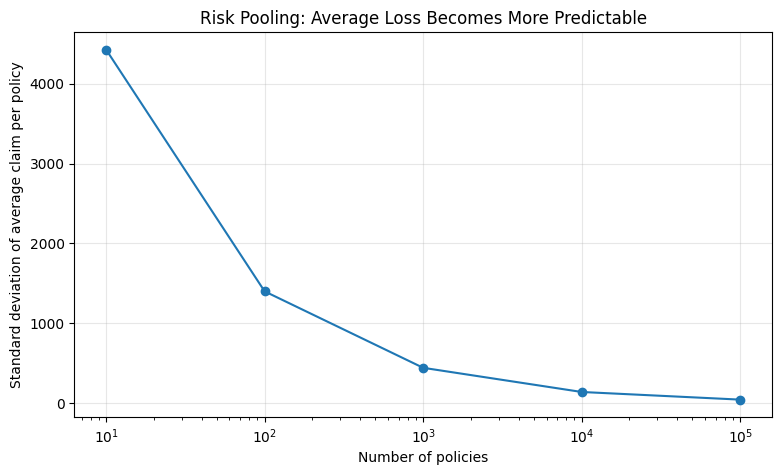

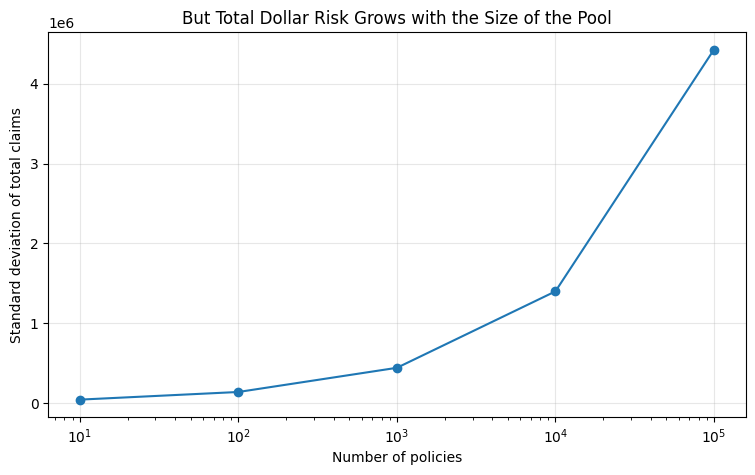

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(N_policies, insurance_table["Std Dev Average Claim per Policy"], marker="o")
plt.xscale("log")
plt.xlabel("Number of policies")
plt.ylabel("Standard deviation of average claim per policy")
plt.title("Risk Pooling: Average Loss Becomes More Predictable")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(N_policies, insurance_table["Std Dev Total Claims"], marker="o")
plt.xscale("log")
plt.xlabel("Number of policies")
plt.ylabel("Standard deviation of total claims")
plt.title("But Total Dollar Risk Grows with the Size of the Pool")
plt.grid(True, alpha=0.3)
plt.show()

The law of large numbers works.

But it works on the average loss per policy, not on total dollar exposure.

If an insurer writes more and more policies without adding capital, investors, reinsurance, or risk-sharing capacity, it can become more predictable per policy while becoming more dangerous in total dollars.

# 11. The Scaling Trap: Do Not Accidentally Scale Up the Bet

The most important practical warning is:

> Diversification does not help if the investor scales up the total bet at the same time.

Consider two different strategies.

## Strategy A: fixed total capital

An investor has fixed capital and spreads it across more independent risks.

As \(N\) rises, the exposure to each individual risk shrinks.

This is true diversification.

## Strategy B: fixed exposure per policy

An insurer adds more policies while keeping the same capital base and the same exposure per policy.

Average loss per policy becomes more predictable, but total dollar exposure grows.

This is not the same thing as making the institution safe.

To safely add policies, the insurer must also add capital providers, reinsurers, or investors.

That is risk sharing.

Suppose a pool of \(N\) independent policies is funded by \(K\) equal investors.

Each investor bears:

$$
\frac{1}{K}
$$

of the aggregate insurance pool.

The exposure of each investor to any one policy is:

$$
\frac{1}{K}
$$

of the policy loss.

If the insurer adds more policies but also adds more investors proportionally, then each investor's exposure to any single policy shrinks or remains controlled.

For example, if \(K=N\), then each investor's exposure to any one policy is:

$$
\frac{1}{N}
$$

of the loss.

As more policies and more investors are added together, no individual investor's exposure to any single policy grows with the number of policies.

In [13]:
# Risk sharing example: exposure per investor under different scaling rules

N = np.array([10, 100, 1_000, 10_000])

fixed_investors = 10
investors_grow_with_policies = N

exposure_per_policy_fixed_K = np.full_like(N, 1 / fixed_investors, dtype=float)
exposure_per_policy_K_equals_N = 1 / investors_grow_with_policies

risk_sharing_table = pd.DataFrame({
    "Policies N": N,
    "Investors K fixed at 10": fixed_investors,
    "Exposure to One Policy per Investor, K=10": exposure_per_policy_fixed_K,
    "Investors K=N": investors_grow_with_policies,
    "Exposure to One Policy per Investor, K=N": exposure_per_policy_K_equals_N
})

risk_sharing_table

,Policies N,Investors K fixed at 10,"Exposure to One Policy per Investor, K=10",Investors K=N,"Exposure to One Policy per Investor, K=N"
0,10,10,0.1000,10,0.1000
1,100,10,0.1000,100,0.0100
2,1000,10,0.1000,1000,0.0010
3,10000,10,0.1000,10000,0.0001


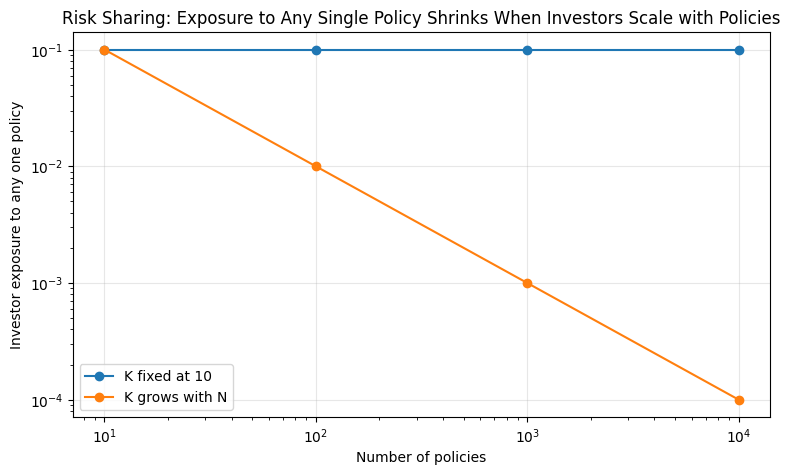

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(N, exposure_per_policy_fixed_K, marker="o", label="K fixed at 10")
plt.plot(N, exposure_per_policy_K_equals_N, marker="o", label="K grows with N")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of policies")
plt.ylabel("Investor exposure to any one policy")
plt.title("Risk Sharing: Exposure to Any Single Policy Shrinks When Investors Scale with Policies")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

When policies grow but capital providers do not, the institution is scaling up the aggregate bet.

When policies and risk-bearing capital grow together, the individual exposures can remain controlled.

This is the distinction between:

- pooling risks statistically,
- sharing risks financially.

# 12. Simulation: Insurance Pool with and without Risk Sharing

We now simulate insurance losses.

Each policy either has no claim or a claim of \(L\).

We compare three quantities:

1. total claims,
2. average claim per policy,
3. claim exposure per investor.

We consider two cases:

- Case 1: the number of investors is fixed.
- Case 2: the number of investors grows with the number of policies.

In [15]:
# Simulate insurance losses for different policy counts

rng = np.random.default_rng(456)

num_sim = 50_000
policy_counts = [100, 1_000, 10_000]
fixed_K = 100

sim_insurance_rows = []

for policy_count in policy_counts:
    claims_count = rng.binomial(policy_count, p, size=num_sim)
    total_claims = claims_count * L
    avg_claim = total_claims / policy_count

    K_fixed = fixed_K
    investor_loss_fixed_K = total_claims / K_fixed

    K_scaled = policy_count
    investor_loss_scaled_K = total_claims / K_scaled

    sim_insurance_rows.append({
        "Policies": policy_count,
        "Mean Total Claims": total_claims.mean(),
        "Std Dev Total Claims": total_claims.std(ddof=1),
        "Mean Avg Claim per Policy": avg_claim.mean(),
        "Std Dev Avg Claim per Policy": avg_claim.std(ddof=1),
        "Mean Investor Loss, Fixed K": investor_loss_fixed_K.mean(),
        "Std Dev Investor Loss, Fixed K": investor_loss_fixed_K.std(ddof=1),
        "Mean Investor Loss, K=N": investor_loss_scaled_K.mean(),
        "Std Dev Investor Loss, K=N": investor_loss_scaled_K.std(ddof=1),
        "95% VaR Investor Loss, Fixed K": np.quantile(investor_loss_fixed_K, 0.95),
        "95% VaR Investor Loss, K=N": np.quantile(investor_loss_scaled_K, 0.95)
    })

sim_insurance_summary = pd.DataFrame(sim_insurance_rows)
sim_insurance_summary

,Policies,Mean Total Claims,Std Dev Total Claims,Mean Avg Claim per Policy,Std Dev Avg Claim per Policy,"Mean Investor Loss, Fixed K","Std Dev Investor Loss, Fixed K","Mean Investor Loss, K=N","Std Dev Investor Loss, K=N","95% VaR Investor Loss, Fixed K","95% VaR Investor Loss, K=N"
0,100,"199,824.0000","139,645.1182","1,998.2400","1,396.4512","1,998.2400","1,396.4512","1,998.2400","1,396.4512","5,000.0000","5,000.0000"
1,1000,"1,998,716.0000","441,993.5051","1,998.7160",441.9935,"19,987.1600","4,419.9351","1,998.7160",441.9935,"28,000.0000","2,800.0000"
2,10000,"20,004,100.0000","1,397,237.0720","2,000.4100",139.7237,"200,041.0000","13,972.3707","2,000.4100",139.7237,"223,000.0000","2,230.0000"


The simulation shows that average loss per policy becomes more stable as the number of policies grows.

But if the number of investors is fixed, the investor's dollar exposure grows with the scale of the insurance pool.

If the number of investors grows with the number of policies, each investor's exposure remains controlled.

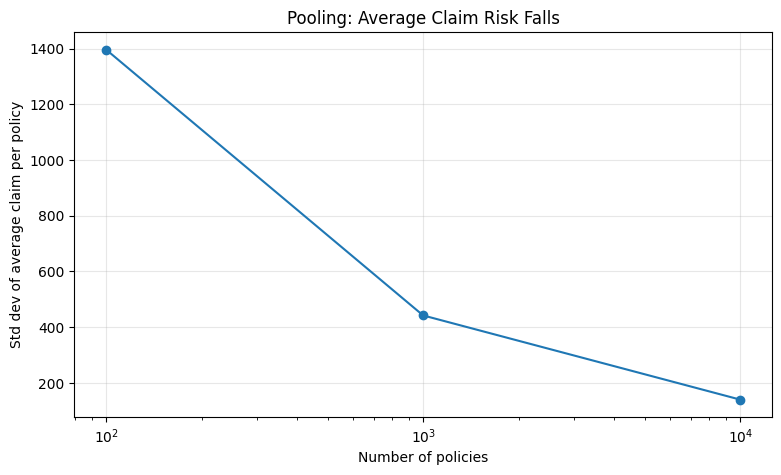

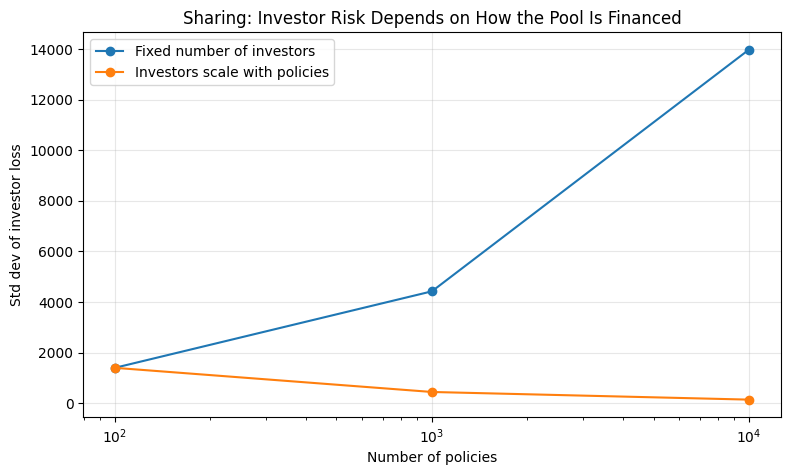

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(sim_insurance_summary["Policies"], sim_insurance_summary["Std Dev Avg Claim per Policy"], marker="o")
plt.xscale("log")
plt.xlabel("Number of policies")
plt.ylabel("Std dev of average claim per policy")
plt.title("Pooling: Average Claim Risk Falls")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(sim_insurance_summary["Policies"], sim_insurance_summary["Std Dev Investor Loss, Fixed K"], marker="o", label="Fixed number of investors")
plt.plot(sim_insurance_summary["Policies"], sim_insurance_summary["Std Dev Investor Loss, K=N"], marker="o", label="Investors scale with policies")
plt.xscale("log")
plt.xlabel("Number of policies")
plt.ylabel("Std dev of investor loss")
plt.title("Sharing: Investor Risk Depends on How the Pool Is Financed")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 13. Connecting Insurance Pooling to Portfolio Diversification

The same logic appears in portfolio management.

A diversified mutual fund or ETF does not usually put a fixed dollar bet on each additional stock while leaving the total fund capital unchanged.

Instead, it reallocates a fixed capital base across more securities.

If the fund has \( \$1 \) of total capital and owns \(N\) equally weighted stocks, each stock receives:

$$
\frac{1}{N}
$$

of the portfolio.

As \(N\) grows, exposure to each individual firm shrinks.

That is why diversification reduces idiosyncratic risk.

But if an investor adds a new full-sized position every time a new asset is added, the investor is not merely diversifying. The investor is expanding the balance sheet.

# 14. Diversification with Fixed Capital Versus Expanding Capital

Suppose each independent risky project has standard deviation \( \sigma \).

## Fixed total capital

Each project receives weight \(1/N\).

Portfolio variance is:

$$
\sigma_p^2 = \frac{\sigma^2}{N}
$$

Risk falls with \(N\).

## Fixed dollar exposure per project

Total exposure rises with \(N\).

Total risk is proportional to:

$$
\sqrt{N}\sigma
$$

Total risk rises with \(N\).

The lesson is:

> The law of large numbers helps when you average independent risks. It does not mean that unlimited expansion of total exposure is safe.

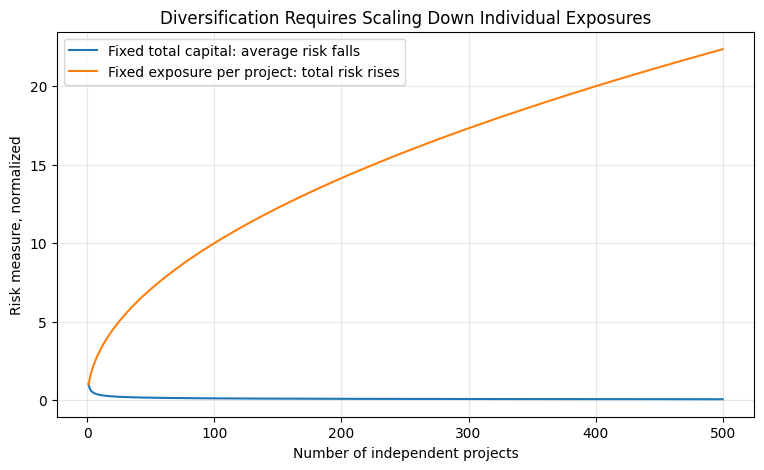

In [17]:
# Fixed capital versus fixed exposure

N_grid = np.arange(1, 501)
sigma_project = 1.0

risk_fixed_capital = sigma_project / np.sqrt(N_grid)
risk_fixed_exposure_per_project = sigma_project * np.sqrt(N_grid)

plt.figure(figsize=(9, 5))
plt.plot(N_grid, risk_fixed_capital, label="Fixed total capital: average risk falls")
plt.plot(N_grid, risk_fixed_exposure_per_project, label="Fixed exposure per project: total risk rises")
plt.xlabel("Number of independent projects")
plt.ylabel("Risk measure, normalized")
plt.title("Diversification Requires Scaling Down Individual Exposures")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This graph is the insurance lesson in one picture.

Pooling works because the average becomes stable.

But if the aggregate exposure grows without more risk-bearing capital, the total risk grows.

# 15. Long-Run Risk for Simple Returns

Financial returns are often reported as simple returns:

$$
R_t = \frac{P_t+D_t-P_{t-1}}{P_{t-1}}
$$

Cumulative wealth is:

$$
W_T = W_0 \prod_{t=1}^T (1+R_t)
$$

The arithmetic average return is:

$$
\bar{R}_T = \frac{1}{T}\sum_{t=1}^T R_t
$$

The geometric average return is:

$$
G_T =
\left(\prod_{t=1}^T (1+R_t)\right)^{1/T}-1
$$

The arithmetic average describes the average one-period return.

The geometric average describes the compound growth rate.

Long-horizon investors ultimately consume wealth, so terminal wealth and geometric growth matter.

In [18]:
# Simulate simple returns using a lognormal process

num_paths = 100_000
T = 30

annual_log_returns = np.random.normal(mu_log, sigma_log, size=(num_paths, T))
simple_returns = np.exp(annual_log_returns) - 1

arithmetic_avg = simple_returns.mean(axis=1)
geometric_avg = np.exp(annual_log_returns.mean(axis=1)) - 1
terminal_wealth = np.exp(annual_log_returns.sum(axis=1))

long_run_simple_summary = pd.DataFrame({
    "Statistic": [
        "Mean arithmetic average return",
        "Std dev arithmetic average return",
        "5th pct arithmetic average return",
        "Mean geometric average return",
        "Std dev geometric average return",
        "5th pct geometric average return",
        "Median terminal wealth",
        "5th pct terminal wealth",
        "1st pct terminal wealth"
    ],
    "Value": [
        arithmetic_avg.mean(),
        arithmetic_avg.std(ddof=1),
        np.quantile(arithmetic_avg, 0.05),
        geometric_avg.mean(),
        geometric_avg.std(ddof=1),
        np.quantile(geometric_avg, 0.05),
        np.median(terminal_wealth),
        np.quantile(terminal_wealth, 0.05),
        np.quantile(terminal_wealth, 0.01)
    ]
})

long_run_simple_summary

,Statistic,Value
0,Mean arithmetic average return,0.0791
1,Std dev arithmetic average return,0.0358
2,5th pct arithmetic average return,0.0211
3,Mean geometric average return,0.0624
4,Std dev geometric average return,0.0350
5,5th pct geometric average return,0.0058
6,Median terminal wealth,6.0396
7,5th pct terminal wealth,1.1904
8,1st pct terminal wealth,0.6081


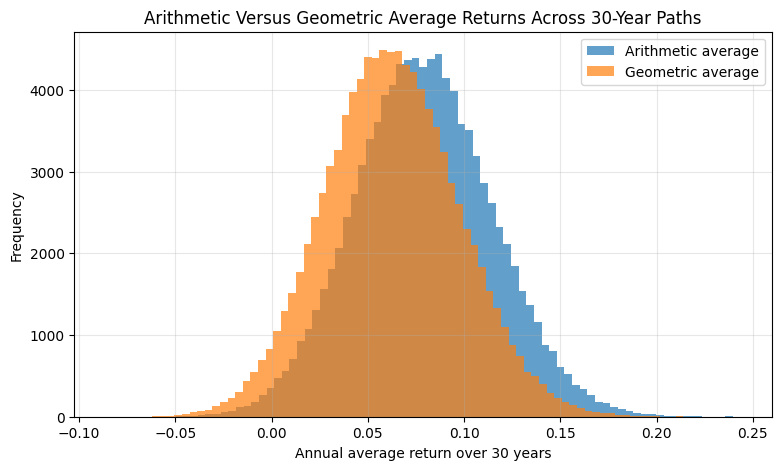

In [19]:
plt.figure(figsize=(9, 5))
plt.hist(arithmetic_avg, bins=80, alpha=0.7, label="Arithmetic average")
plt.hist(geometric_avg, bins=80, alpha=0.7, label="Geometric average")
plt.xlabel("Annual average return over 30 years")
plt.ylabel("Frequency")
plt.title("Arithmetic Versus Geometric Average Returns Across 30-Year Paths")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The geometric average is usually lower than the arithmetic average because volatility reduces compound growth.

This is another way to see why long-run investing cannot be reduced to the arithmetic mean alone.

# 16. Worked Example: The Same Average Return Can Hide Very Different Terminal Wealth

Consider two paths over four years.

Path A:

$$
10\%, 10\%, 10\%, 10\%
$$

Path B:

$$
40\%, -20\%, 30\%, -10\%
$$

Both may have similar arithmetic averages, but the terminal wealth can differ materially.

Volatility affects compounding.

In [20]:
path_A = np.array([0.10, 0.10, 0.10, 0.10])
path_B = np.array([0.40, -0.20, 0.30, -0.10])

paths = {"Path A": path_A, "Path B": path_B}

rows = []
wealth_paths = {}

for name, r in paths.items():
    wealth = np.cumprod(1 + r)
    wealth_paths[name] = wealth
    rows.append({
        "Path": name,
        "Arithmetic Average": r.mean(),
        "Geometric Average": wealth[-1]**(1/len(r))-1,
        "Terminal Wealth from $1": wealth[-1],
        "Standard Deviation": r.std(ddof=1)
    })

pd.DataFrame(rows)

,Path,Arithmetic Average,Geometric Average,Terminal Wealth from $1,Standard Deviation
0,Path A,0.1000,0.1000,1.4641,0.0000
1,Path B,0.1000,0.0699,1.3104,0.2944


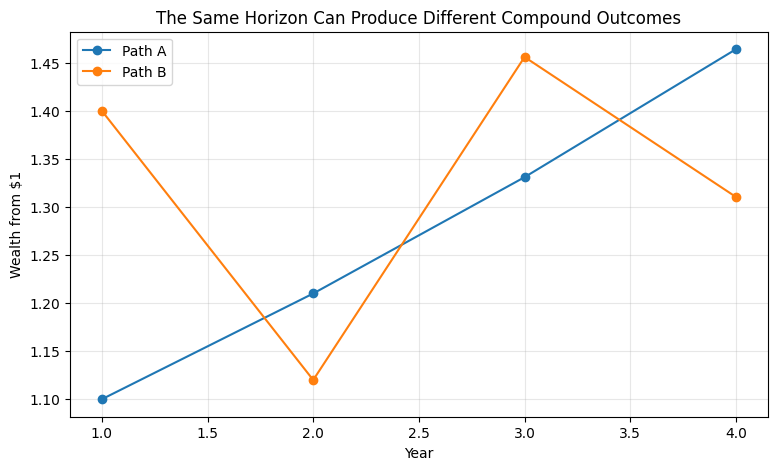

In [21]:
plt.figure(figsize=(9, 5))
for name, wealth in wealth_paths.items():
    plt.plot(np.arange(1, len(wealth)+1), wealth, marker="o", label=name)

plt.xlabel("Year")
plt.ylabel("Wealth from $1")
plt.title("The Same Horizon Can Produce Different Compound Outcomes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Volatility matters because returns compound multiplicatively.

Large losses are especially damaging because the gain required to recover is larger than the loss.

For example, after a 50% loss, a portfolio needs a 100% gain to break even.

In [22]:
losses = np.array([0.10, 0.20, 0.30, 0.50, 0.70, 0.90])
required_gains = losses / (1 - losses)

pd.DataFrame({
    "Loss": losses,
    "Gain Required to Recover": required_gains
})

,Loss,Gain Required to Recover
0,0.1000,0.1111
1,0.2000,0.2500
2,0.3000,0.4286
3,0.5000,1.0000
4,0.7000,2.3333
5,0.9000,9.0000


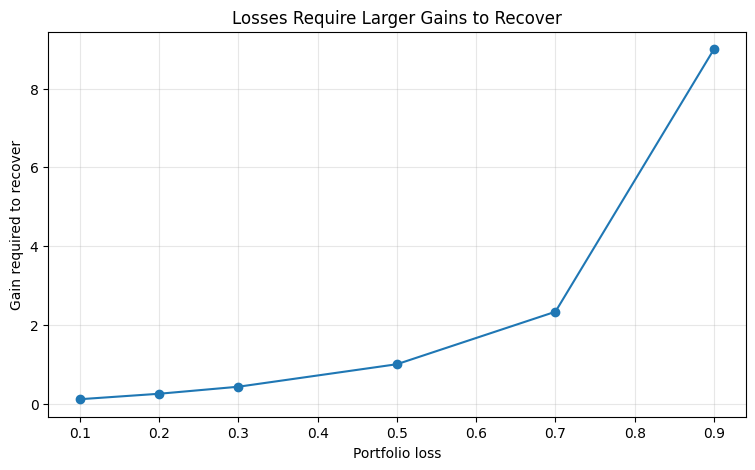

In [23]:
plt.figure(figsize=(9, 5))
plt.plot(losses, required_gains, marker="o")
plt.xlabel("Portfolio loss")
plt.ylabel("Gain required to recover")
plt.title("Losses Require Larger Gains to Recover")
plt.grid(True, alpha=0.3)
plt.show()

# 17. Why the Long Run Does Not Eliminate Risk

There are three reasons long-run risk remains economically important.

## First, terminal wealth matters

Investors ultimately care about the resources they can consume, donate, bequeath, or use to fund liabilities.

Terminal wealth is cumulative.

## Second, compounding is multiplicative

Bad early returns reduce the capital base on which later returns compound.

## Third, risk may not be independent and identically distributed

The formulas above assumed independent returns with stable parameters.

Real returns can exhibit:

- changing volatility,
- changing expected returns,
- valuation effects,
- inflation regimes,
- liquidity crises,
- serial correlation,
- tail dependence,
- structural breaks.

Long-horizon inference is therefore more difficult than the clean textbook model suggests.

# 18. Sequence Risk

Sequence risk is the risk that the order of returns matters.

For an investor who never adds or withdraws money, the order of returns does not affect terminal wealth if the set of annual returns is fixed.

For example:

$$
(1+R_1)(1+R_2) = (1+R_2)(1+R_1)
$$

But for an investor making contributions or withdrawals, order matters greatly.

Retirees are especially exposed to sequence risk because withdrawals after early losses can permanently impair the capital base.

In [24]:
# Sequence risk demonstration with withdrawals

returns_good_first = np.array([0.20, 0.15, 0.10, 0.05, -0.05, -0.10, -0.15, -0.20])
returns_bad_first = returns_good_first[::-1]

initial_wealth = 1_000_000
withdrawal = 60_000

def simulate_withdrawal_path(returns, initial_wealth, withdrawal):
    wealth = [initial_wealth]
    current = initial_wealth
    for r in returns:
        current = current * (1 + r)
        current = current - withdrawal
        wealth.append(current)
    return np.array(wealth)

wealth_good_first = simulate_withdrawal_path(returns_good_first, initial_wealth, withdrawal)
wealth_bad_first = simulate_withdrawal_path(returns_bad_first, initial_wealth, withdrawal)

pd.DataFrame({
    "Year": np.arange(len(wealth_good_first)),
    "Good Returns First": wealth_good_first,
    "Bad Returns First": wealth_bad_first
})

,Year,Good Returns First,Bad Returns First
0,0,"1,000,000.0000","1,000,000.0000"
1,1,"1,140,000.0000","740,000.0000"
2,2,"1,251,000.0000","569,000.0000"
3,3,"1,316,100.0000","452,100.0000"
4,4,"1,321,905.0000","369,495.0000"
5,5,"1,195,809.7500","327,969.7500"
6,6,"1,016,228.7750","300,766.7250"
7,7,"803,794.4588","285,881.7338"
8,8,"583,035.5670","283,058.0805"


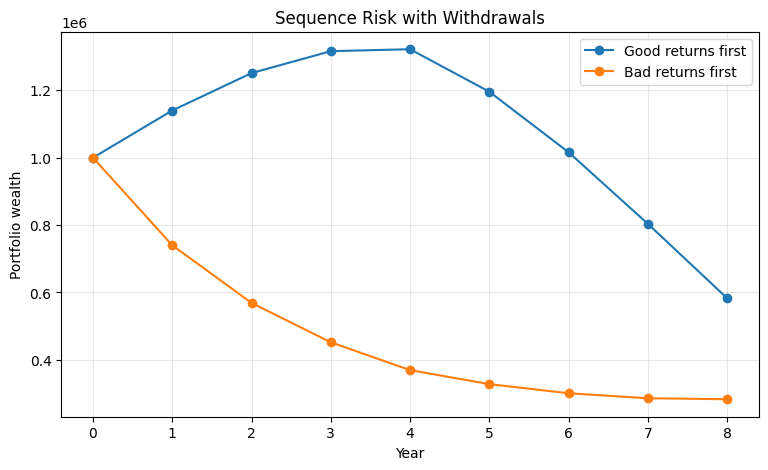

In [25]:
plt.figure(figsize=(9, 5))
plt.plot(wealth_good_first, marker="o", label="Good returns first")
plt.plot(wealth_bad_first, marker="o", label="Bad returns first")
plt.xlabel("Year")
plt.ylabel("Portfolio wealth")
plt.title("Sequence Risk with Withdrawals")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The same returns in a different order produce different wealth paths when withdrawals occur.

This is another reason the long run does not make risk irrelevant.

# 19. Risk Premiums and Horizon

A risky asset may have a positive expected excess return:

$$
\mathbb{E}[R] - R_f > 0
$$

Over long horizons, that risk premium has more time to compound.

This is the strongest argument for long-run risky investing.

But the existence of a positive risk premium does not mean the risk disappears.

Instead, long-run investment involves a tradeoff:

- higher expected terminal wealth,
- wider distribution of terminal wealth.

The risk premium is compensation for bearing risk, not proof that the risk is gone.

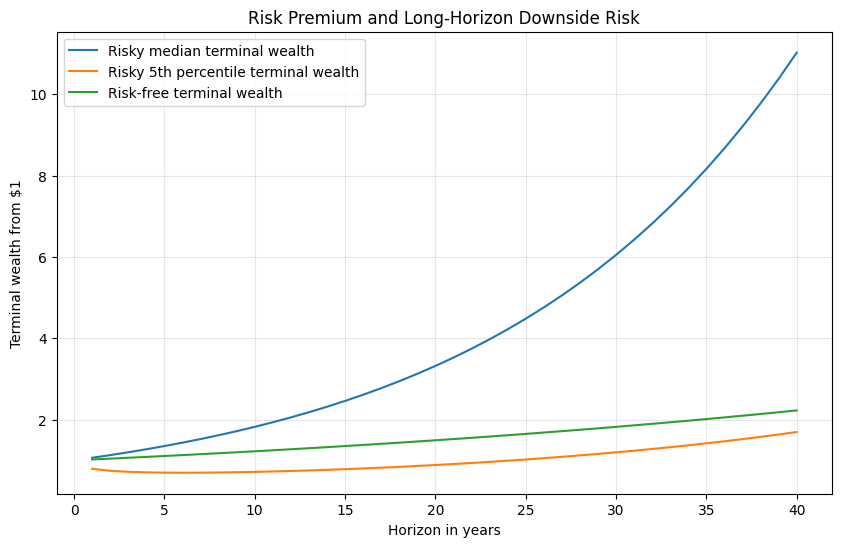

In [26]:
# Long-run terminal wealth for risky asset versus risk-free asset

rf_log = 0.02
horizons_compare = np.arange(1, 41)

mean_log_risky = horizons_compare * mu_log
std_log_risky = np.sqrt(horizons_compare) * sigma_log

median_wealth_risky = np.exp(mean_log_risky)
p05_wealth_risky = np.exp(mean_log_risky + z_05 * std_log_risky)

wealth_rf = np.exp(rf_log * horizons_compare)

plt.figure(figsize=(10, 6))
plt.plot(horizons_compare, median_wealth_risky, label="Risky median terminal wealth")
plt.plot(horizons_compare, p05_wealth_risky, label="Risky 5th percentile terminal wealth")
plt.plot(horizons_compare, wealth_rf, label="Risk-free terminal wealth")
plt.xlabel("Horizon in years")
plt.ylabel("Terminal wealth from $1")
plt.title("Risk Premium and Long-Horizon Downside Risk")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The risky asset's median outcome grows faster than the risk-free asset when the assumed risk premium is positive.

But the lower-tail outcome can still be poor over economically relevant horizons.

Long-horizon investing is not magic. It is compensation for bearing risk over time.

# 20. Summary of Key Formulas

## Average annual arithmetic return

$$
\bar{R}_T = \frac{1}{T}\sum_{t=1}^T R_t
$$

## Variance of average return under independence

$$
\operatorname{Var}(\bar{R}_T)=\frac{\sigma^2}{T}
$$

## Cumulative simple return

$$
R_{0,T}=\prod_{t=1}^T(1+R_t)-1
$$

## Cumulative log return

$$
r_{0,T}=\sum_{t=1}^T r_t
$$

## Variance of cumulative log return

$$
\operatorname{Var}(r_{0,T})=T\sigma^2
$$

## Standard deviation of cumulative log return

$$
\operatorname{Std}(r_{0,T})=\sqrt{T}\sigma
$$

## Standard deviation of average annual log return

$$
\operatorname{Std}(\bar{r}_T)=\frac{\sigma}{\sqrt{T}}
$$

## Expected total insurance claims

$$
\mathbb{E}[X_N]=NpL
$$

## Standard deviation of total insurance claims

$$
\operatorname{Std}(X_N)=\sqrt{Np(1-p)}L
$$

## Standard deviation of average claim per policy

$$
\operatorname{Std}(\bar{X}_N)=\frac{\sqrt{p(1-p)}L}{\sqrt{N}}
$$

# 21. Final Takeaways

1. The average annual return becomes more predictable as the horizon grows.

2. Cumulative return and terminal wealth become more dispersed as the horizon grows.

3. Time diversification is often overstated because it confuses average-return risk with terminal-wealth risk.

4. The law of large numbers applies to averages, not to unlimited scaling of total exposure.

5. Risk pooling makes average loss per exposure more predictable.

6. Risk sharing determines who bears the aggregate loss.

7. An insurer that writes more policies must also scale capital, reinsurance, or investors.

8. A diversified investor reduces exposure to each individual risk as the number of positions grows.

9. A positive risk premium compensates investors for bearing long-run risk; it does not make risky assets safe.

10. In long-run investment analysis, always specify the risk object: average annual return, cumulative return, terminal wealth, shortfall probability, or Value at Risk.